In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

In [2]:
with open("../saved_models/features.json") as f:
    feature_names = json.load(f)

In [3]:
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [4]:
df = pd.read_csv("../data/processed/final_dataset2.csv", parse_dates=["timestamp"])
print("[INFO] Loaded dataset:", df.shape)
df.head(3)

[INFO] Loaded dataset: (87650, 7)


,timestamp,load_actual,temperature,humidity,dew_point,solar_generation,wind_generation
0,2014-12-31 23:00:00,9484.0,0.5,96.0,-0.1,92.66,734.81
1,2015-01-01 00:00:00,9484.0,0.1,95.0,-0.5,92.66,734.81
2,2015-01-01 01:00:00,9152.0,-0.2,95.0,-0.9,92.66,734.81


In [5]:
target = "load_actual"

X = df[feature_names]          # FIXED
y = df[target].values.reshape(-1, 1)


In [6]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)


In [7]:
def create_sequences(X, y, lookback=24):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i - lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

lookback = 24
X_seq, y_seq = create_sequences(X_scaled, y_scaled, lookback)


In [8]:
train_size = int(len(X_seq) * 0.8)

X_train = X_seq[:train_size]
X_test  = X_seq[train_size:]

y_train = y_seq[:train_size]
y_test  = y_seq[train_size:]


In [9]:
n_timesteps = X_train.shape[1]   # 24
n_features = X_train.shape[2]    # number of features

tf.keras.backend.clear_session()

model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(n_timesteps, n_features)),
    MaxPooling1D(pool_size=2),

    Conv1D(32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),

    LSTM(64),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dropout(0.1),

    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 22, 64)         │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 11, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 9, 32)          │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,145 (133.38 KB)

 Trainable params: 34,145 (133.38 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
checkpoint_path = "../saved_models/cnn_lstm_best.keras"

checkpoint_cb = ModelCheckpoint(
    checkpoint_path,
    save_best_only=True,
    monitor="val_loss"
)

early_cb = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.1,
    callbacks=[checkpoint_cb, early_cb],
    verbose=1
)


Epoch 1/40
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.0191 - val_loss: 0.0132
Epoch 2/40
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0139 - val_loss: 0.0133
Epoch 3/40
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0131 - val_loss: 0.0132
Epoch 4/40
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0127 - val_loss: 0.0122
Epoch 5/40
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0125 - val_loss: 0.0120
Epoch 6/40
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0124 - val_loss: 0.0118
Epoch 7/40
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0122 - val_loss: 0.0120
Epoch 8/40
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0121 - val_loss: 0.0117
Epoch 9/40
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0120 - val_loss: 0.0122
Epoch 10/40
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0119 - val_loss: 0.0116
Epoch 11/40
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.0118 - val_loss: 0.0115
Epoch 12/40
1972/1972 ━━━━━━━━

In [11]:
best_model = load_model(checkpoint_path)

pred_scaled = best_model.predict(X_test)
pred = scaler_y.inverse_transform(pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test)


548/548 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [12]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true).reshape(-1,), np.array(y_pred).reshape(-1,)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

mae_cnn_lstm = mean_absolute_error(y_test_actual, pred)
rmse_cnn_lstm = mean_squared_error(y_test_actual, pred) ** 0.5
mape_cnn_lstm = mape(y_test_actual, pred)

print("CNN-LSTM Results:")
print("MAE:", mae_cnn_lstm)
print("RMSE:", rmse_cnn_lstm)
print("MAPE:", mape_cnn_lstm)


CNN-LSTM Results:
MAE: 533.6762826572894
RMSE: 694.9038315378418
MAPE: 5.567700424679624


In [13]:
best_model.save("../saved_models/cnn_lstm_model.h5")
joblib.dump(scaler_X, "../saved_models/cnn_lstm_scaler_X.pkl")
joblib.dump(scaler_y, "../saved_models/cnn_lstm_scaler_y.pkl")

print("[INFO] Model + Scalers saved.")

[INFO] Model + Scalers saved.


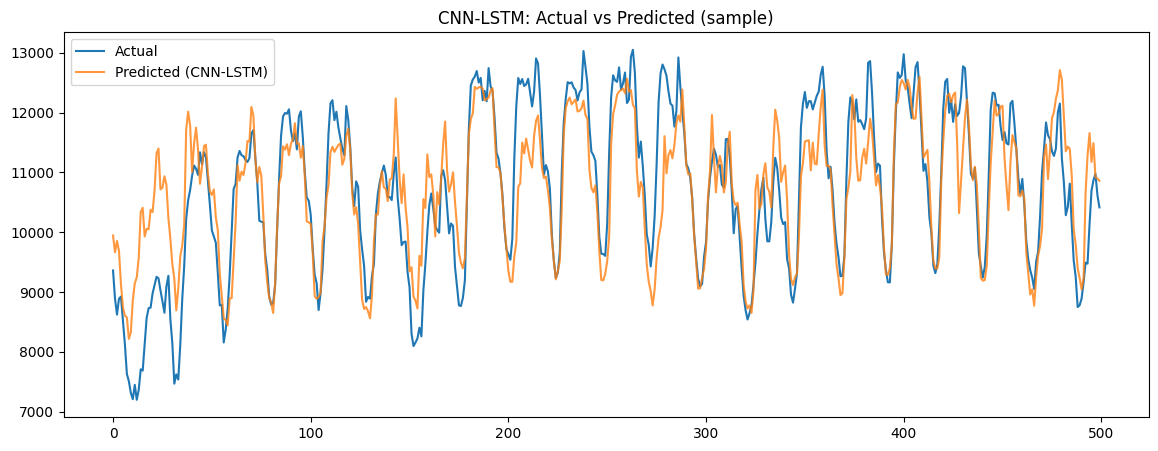

In [14]:
plt.figure(figsize=(14,5))
plt.plot(y_test_actual[:500], label="Actual")
plt.plot(pred[:500], label="Predicted (CNN-LSTM)", alpha=0.8)
plt.legend()
plt.title("CNN-LSTM: Actual vs Predicted (sample)")
plt.show()
